<a href="https://colab.research.google.com/github/lucasamaralr10/modelo-analitico-zagueiros/blob/main/C%C3%B3pia_de_LUCAS_AMARAL_DESAFIO_FINAL_ANALISE_DE_DADOS_VERSAO_GITHUB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -*- coding: utf-8 -*-
"""LUCAS AMARAL - DESAFIO FINAL ANALISE DE DADOS (PROJETO COMPLETO)

Este notebook implementa um modelo avançado de Football Analytics para a
avaliação, benchmarking e prospecção de zagueiros com base em dados de
performance volumétricos e de eficiência técnica (FBref & Wyscout).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import matplotlib.colors as mcolors
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# ==============================================================================
# 1. CARGA E PREPARAÇÃO DOS DADOS BRUTOS
# ==============================================================================

# Carregamento das planilhas de scout técnico extraídas do FBref e Wyscout
df_defensive_stats = pd.read_excel('DEFENSE_BRASILEIRAO.xlsx')
df_miscellaneous_stats = pd.read_excel('MISC_BRASILEIRAO.xlsx')
df_stats_standard = pd.read_excel('STATS_STANDARD_BRASILEIRAO.xlsx')
df_adv_goalkeeping_teamsbr24 = pd.read_excel('SQUAD_ADVANCED_GOALKEEPING_BR24.xlsx')
df_possession_teamsbr24 = pd.read_excel('SQUAD_POSSESSION_BR24.xlsx')

# Geração de cópias de segurança (Checkpoints) para manipulação dos dados
df_defensive_stats_copy = df_defensive_stats.copy()
df_miscellaneous_stats_copy = df_miscellaneous_stats.copy()
df_stats_standard_copy = df_stats_standard.copy()
df_adv_goalkeeping_teamsbr24_copy = df_adv_goalkeeping_teamsbr24.copy()
df_possession_teamsbr24_copy = df_possession_teamsbr24.copy()

# Alinhamento e definição da primeira linha como cabeçalho de colunas estruturadas
df_defensive_stats_copy.columns = df_defensive_stats_copy.iloc[0]
df_miscellaneous_stats_copy.columns = df_miscellaneous_stats_copy.iloc[0]
df_stats_standard_copy.columns = df_stats_standard_copy.iloc[0]
df_adv_goalkeeping_teamsbr24_copy.columns = df_adv_goalkeeping_teamsbr24_copy.iloc[0]
df_possession_teamsbr24_copy.columns = df_possession_teamsbr24_copy.iloc[0]

# Exclusão da linha inicial de metadados duplicados pós-ajuste de colunas
df_defensive_stats_copy = df_defensive_stats_copy.iloc[1:]
df_miscellaneous_stats_copy = df_miscellaneous_stats_copy.iloc[1:]
df_stats_standard_copy = df_stats_standard_copy.iloc[1:]
df_adv_goalkeeping_teamsbr24_copy = df_adv_goalkeeping_teamsbr24_copy.iloc[1:]
df_possession_teamsbr24_copy = df_possession_teamsbr24_copy.iloc[1:]

# Saneamento de dados: eliminação de colunas residuais de indexação e linhas vazias repetidas
df_defensive_stats_copy = df_defensive_stats_copy.drop(columns=['Rk'], errors='ignore')
df_defensive_stats_copy = df_defensive_stats_copy.drop_duplicates()
df_defensive_stats_copy = df_defensive_stats_copy[df_defensive_stats_copy['Player'] != 'Player']

# Padronização de nomenclatura de variáveis de scout coletivo
df_adv_goalkeeping_teamsbr24_copy = df_adv_goalkeeping_teamsbr24_copy.rename(columns={'Opp': 'Crosses Faced'})


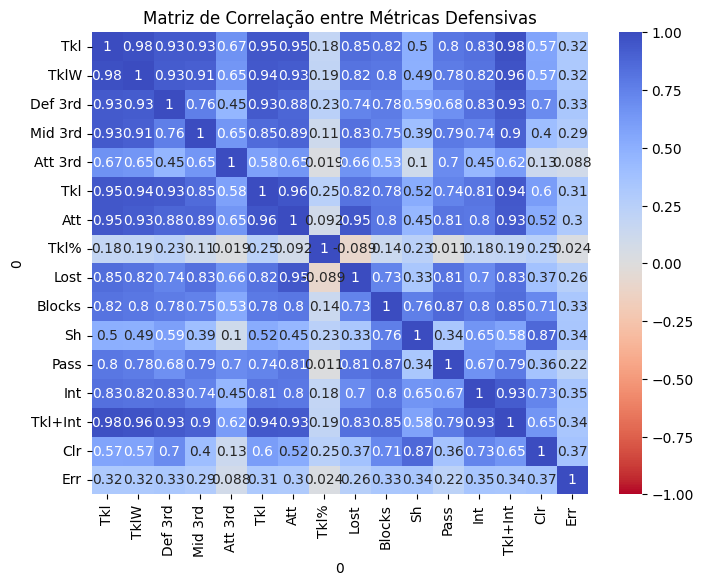

In [ ]:
# ==============================================================================
# 2. ANÁLISE EXPLORATÓRIA INICIAL E MATRIZ DE CORRELAÇÃO
# ==============================================================================

# Coerção temporária para tipo numérico para viabilizar o cálculo correto da correlação (Pandas 2.0+)
df_corr_temp = df_defensive_stats_copy.drop(columns=[
    'Player','Nation','Age','Born','Pos','90s','Squad', 'Player_key_FBREF',
    'Pos_Wyscout', 'Match_Wyscout','Pos_FINAL', 'AGE_Wyscout'
], errors='ignore').apply(pd.to_numeric, errors='coerce')

# Geração de matriz e plotagem de mapa de calor de correlações lineares
def_stats_corr_matrix = df_corr_temp.corr()
plt.figure(figsize=(8,6))
sns.heatmap(def_stats_corr_matrix, annot=True, cmap='coolwarm_r', vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Métricas Defensivas')
plt.show()

# Isolação seletiva de features cruciais para a estrutura analítica final
df_defensivo = df_defensive_stats_copy[['Player', 'Def 3rd', 'Sh', 'Clr','Squad','Int', 'Tkl%']].copy()
df_misc = df_miscellaneous_stats_copy[['Player', 'Won', 'Lost', 'Won%', 'Squad']].copy()
df_stats = df_stats_standard_copy[['Player', 'Min','Squad','Pos','Age']].copy()
df_crosses_faced = df_adv_goalkeeping_teamsbr24_copy[['Squad', 'Crosses Faced']].copy()
df_possession = df_possession_teamsbr24_copy[['Squad', 'Poss']].copy()

In [ ]:
# ==============================================================================
# 3. FILTRAGEM DE ELEGIBILIDADE E INTEGRAÇÃO VETORIZADA (MERGE)
# ==============================================================================

# Nota metodológica: Limiar de minutagem fixado em >= 798 minutos para fins de amostragem
# regulamentar e inclusão representativa de atletas específicos do campeonato (Ex: Jhonathan Jesus).
df_base = (
    df_stats[(df_stats['Min'] >= 798) & (df_stats['Age'] <= 35)][['Player','Squad','Min','Pos','Age']]
    .merge(df_defensivo, on=['Player','Squad'], how='left')
    .merge(df_misc, on=['Player','Squad'], how='left')
    .merge(df_possession[['Squad','Poss']], on='Squad', how='left')
    .merge(df_crosses_faced[['Squad','Crosses Faced']], on='Squad', how='left')
)

# Coerção formal e definitiva de dados das colunas numéricas de performance
cols_num = ['Def 3rd', 'Sh', 'Clr', 'Won', 'Lost', 'Won%', 'Crosses Faced', 'Min', 'Poss', 'Int', 'Tkl%']
df_base[cols_num] = df_base[cols_num].apply(pd.to_numeric, errors='coerce')

In [ ]:
# ==============================================================================
# 4. ENGENHARIA DE FEATURES: ENGENHARIA DO MODELO DEFENSIVO
# ==============================================================================

"""
1. Construção das Métricas Base com Ajuste por Tempo de Jogo (por 90 minutos)
Todas as métricas defensivas são inicialmente padronizadas por 90 minutos,
garantindo comparabilidade equitativa entre jogadores com diferentes volumes de minutos.

2. Ajuste pelo Contexto de Posse de Bola (PAdj)
Para evitar a subavaliação de defensores pertencentes a equipes dominantes que passam
longos períodos com a bola, as métricas foram ajustadas pelo tempo de não-posse coletiva.

3. Aerial Score — Impacto Aéreo Contextualizado
Captura o impacto real do jogo aéreo unindo o volume individual por 90 minutos,
o contexto coletivo de exposição a cruzamentos do time e a eficiência percentual de duelos.
"""

# 4.1. Cálculo de Impacto Aéreo Contextualizado
df_base['Won_per90'] = df_base['Won'] / (df_base['Min']/90)
df_base['Crosses_Faced_per90'] = df_base['Crosses Faced'] / (3420/90)

df_base['Aerial_Context'] = df_base['Won_per90'] / df_base['Crosses_Faced_per90']
df_base['Aerial_Efficiency'] = df_base['Won%'] / 100
df_base['Aerial_Score'] = df_base['Aerial_Context'] * df_base['Aerial_Efficiency']

# 4.2. Cálculo de Frequência Volumétrica por 90 Minutos
df_base['def3rd_p90'] = df_base['Def 3rd'] / (df_base['Min'] / 90)
df_base['block_sh_p90'] = df_base['Sh'] / (df_base['Min'] / 90)
df_base['Clr_p90'] = df_base['Clr'] / (df_base['Min'] / 90)
df_base['Int_p90'] = df_base['Int'] / (df_base['Min'] / 90)

# 4.3. Aplicação do Ajuste por Não-Posse de Bola (Possession-Adjusted Stats / PAdj)
df_base['Nao_Poss'] = (100 - df_base['Poss']) / 100
df_base['def3rd_adj'] = df_base['def3rd_p90'] / df_base['Nao_Poss']
df_base['block_sh_adj'] = df_base['block_sh_p90'] / df_base['Nao_Poss']
df_base['Clr_adj'] = df_base['Clr_p90'] / df_base['Nao_Poss']
df_base['Int_adj'] = df_base['Int_p90'] / df_base['Nao_Poss']

# 4.4. Modelagem de Eficiência Técnica de Desarmes no Terço Defensivo
df_base['Tkl_Eff'] = df_base['Tkl%'] / 100
df_base['def3rd_eff'] = df_base['def3rd_adj'] * df_base['Tkl_Eff']

In [ ]:
# ==============================================================================
# 5. ANÁLISE INTRAGRUPO E COMPORTAMENTO AÉREO (Z-SCORE COLETIVO)
# ==============================================================================

"""
4. Aerial Participation — Protagonismo Relativo do Atleta Dentro do Elenco
Mede a taxa de contribuição de duelos aéreos ganhos pelo jogador em relação ao somatório
geral do setor defensivo do próprio clube. A variável é padronizada via Z-Score por equipe,
neutralizando distorções estruturais e isolando o real protagonista aéreo do elenco.
"""

# Isolamento e agregação da volumetria aérea coletiva de todos os defensores por equipe
df_team_def = df_base[df_base['Pos'].str.contains('CB|LCB|RCB|DF', regex=True)].copy()
team_aerial = df_team_def.groupby('Squad')[['Won']].sum().rename(columns={'Won':'Team_Won'})
df_team_def = df_team_def.merge(team_aerial, on='Squad', how='left')
df_team_def['Aerial_Participation'] = df_team_def['Won'] / df_team_def['Team_Won']

# Geração de Z-Score intragrupo
df_team_def['Aerial_Participation_z'] = df_team_def.groupby('Squad')['Aerial_Participation'].transform(zscore)

In [ ]:
# ==============================================================================
# 6. NORMALIZAÇÃO (MIN-MAX) E COMPOSIÇÃO DOS PESOS DO DEFSCORE
# ==============================================================================

# Inicializando o normalizador escala 0 a 1
scaler = MinMaxScaler()

# Definindo as colunas numéricas que serão normalizadas
cols_norm = ['Aerial_Score', 'def3rd_eff', 'block_sh_adj', 'Clr_adj', 'Int_adj']

# Aplicando a transformação e criando as colunas com sufixo '_final'
df_zagueiros[[col + '_final' for col in cols_norm]] = scaler.fit_transform(df_zagueiros[cols_norm])

# Distribuição ponderada de pesos (Modelo Multicritério)
df_zagueiros['DefScore_base'] = (
    0.15 * df_zagueiros['Aerial_Score_final'] +
    0.35 * df_zagueiros['def3rd_eff_final'] +
    0.20 * df_zagueiros['Int_adj_final'] +
    0.15 * df_zagueiros['block_sh_adj_final'] +
    0.15 * df_zagueiros['Clr_adj_final']
)

# Aplicação do fator multiplicador baseado no Z-Score Aéreo Coletivo
df_zagueiros['DefScore_final'] = df_zagueiros['DefScore_base'] * (1 + 0.1 * df_zagueiros['Aerial_Participation_z'])

# Ordenação sistemática do ranking geral
df_ranking_def = df_zagueiros[[
    'Player', 'Age', 'Squad', 'Pos', 'DefScore_final',
    'Aerial_Score_final', 'def3rd_eff_final', 'Int_adj_final',
    'block_sh_adj_final', 'Clr_adj_final', 'Aerial_Participation',
    'Aerial_Participation_z'
]].sort_values('DefScore_final', ascending=False).reset_index(drop=True)


In [ ]:
# Benchmarking da Competição vs Média da Liga (Seção 7)
# Lista de métricas brutas por 90 minutos para a comparação setorial
cols_p90 = ['def3rd_p90', 'Int_p90', 'block_sh_p90', 'Clr_p90', 'Aerial_Score']

# Geração das médias coletivas para criar o benchmark global
liga_media = df_base[cols_p90].mean().to_frame(name='Média_Liga')
liga_media.index.name = 'Métrica'
liga_media.reset_index(inplace=True)

# Cruzamento vetorizado dos dados do Top 10 com a base global (Substituindo o laço for)
top_defscore = df_zagueiros.sort_values('DefScore_final', ascending=False).head(10)
ranking_comparativo = top_defscore[['Player', 'Squad', 'DefScore_final']].merge(
    df_base[['Player', 'Squad'] + cols_p90], on=['Player', 'Squad'], how='left'
)

# Indexação rápida e cálculo da variação delta (Atleta vs Média Geral de Mercado)
liga_media_indexada = liga_media.set_index('Métrica')
for col in cols_p90:
    ranking_comparativo[f'{col}_vs_Liga'] = (
        ranking_comparativo[col] - liga_media_indexada.loc[col, 'Média_Liga']
    )

# Ordenação final da tabela de comparação analítica
ranking_comparativo = ranking_comparativo.sort_values(by='DefScore_final', ascending=False).reset_index(drop=True)

# Exibição do resultado tabular estruturado na tela do Colab
ranking_comparativo



,Player,Squad,DefScore_final,def3rd_p90,Int_p90,block_sh_p90,Clr_p90,Aerial_Score,def3rd_p90_vs_Liga,Int_p90_vs_Liga,block_sh_p90_vs_Liga,Clr_p90_vs_Liga,Aerial_Score_vs_Liga
0,Vitor Hugo,Atlético Mineiro,0.782551,1.043319,1.427700,0.878585,6.259915,0.182719,0.312535,0.673196,0.561623,3.903523,0.136749
1,Alexander Barboza,Botafogo (RJ),0.761804,1.592920,0.922217,0.628784,6.958547,0.148335,0.862136,0.167713,0.311823,4.602155,0.102365
2,João Victor,Vasco da Gama,0.728601,1.442509,0.627178,0.689895,6.209059,0.142345,0.711724,-0.127327,0.372934,3.852667,0.096375
3,Gustavo Gómez,Palmeiras,0.704879,1.168831,1.363636,0.935065,5.532468,0.169437,0.438047,0.609132,0.618104,3.176075,0.123467
4,Lyanco,Atlético Mineiro,0.704714,1.404255,2.361702,0.829787,5.106383,0.110995,0.673471,1.607198,0.512826,2.749991,0.065025
5,Victor Gabriel,Internacional,0.691903,1.136159,1.460775,0.973850,7.709648,0.164669,0.405374,0.706271,0.656889,5.353256,0.118700
6,Ignácio,Fluminense,0.631589,1.412380,1.176983,0.863121,7.375763,0.096696,0.681596,0.422479,0.546160,5.019371,0.050727
7,Gustavo Henrique,Corinthians,0.621756,0.869565,0.782609,1.000000,5.434783,0.195241,0.138781,0.028104,0.683039,3.078391,0.149271
8,Rodrigo Sam,Juventude,0.605960,1.606040,1.667811,0.494166,6.362388,0.138461,0.875255,0.913306,0.177205,4.005996,0.092491
9,EDU,Vitória,0.573815,2.178771,0.921788,0.502793,8.044693,0.064066,1.447986,0.167283,0.185832,5.688301,0.018097


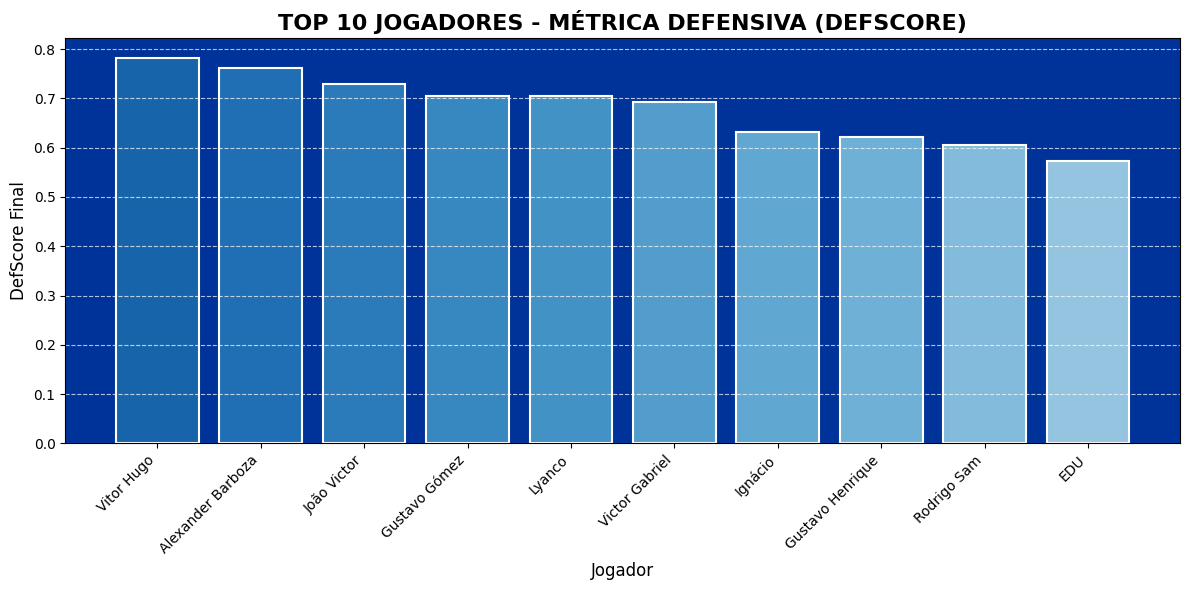

In [ ]:
# Visualização do Top 10 DefScores Geral (Seção 8.1)

# Isolando os 10 melhores zagueiros classificados pelo modelo
top10 = df_ranking_def.sort_values('DefScore_final', ascending=False).head(10)
colors_bar = plt.cm.Blues(np.linspace(0.8, 0.4, len(top10)))

# Configuração e renderização estética do gráfico de barras principal
plt.figure(figsize=(12, 6))
plt.bar(top10['Player'], top10['DefScore_final'], color=colors_bar, edgecolor='white', linewidth=1.5)
plt.title('TOP 10 JOGADORES - MÉTRICA DEFENSIVA (DEFSCORE)', fontsize=16, fontweight='bold')
plt.xlabel('Jogador', fontsize=12)
plt.ylabel('DefScore Final', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.gca().set_facecolor('#003399')
plt.grid(axis='y', linestyle='--', alpha=0.7, color='white')
plt.tight_layout()
plt.show()


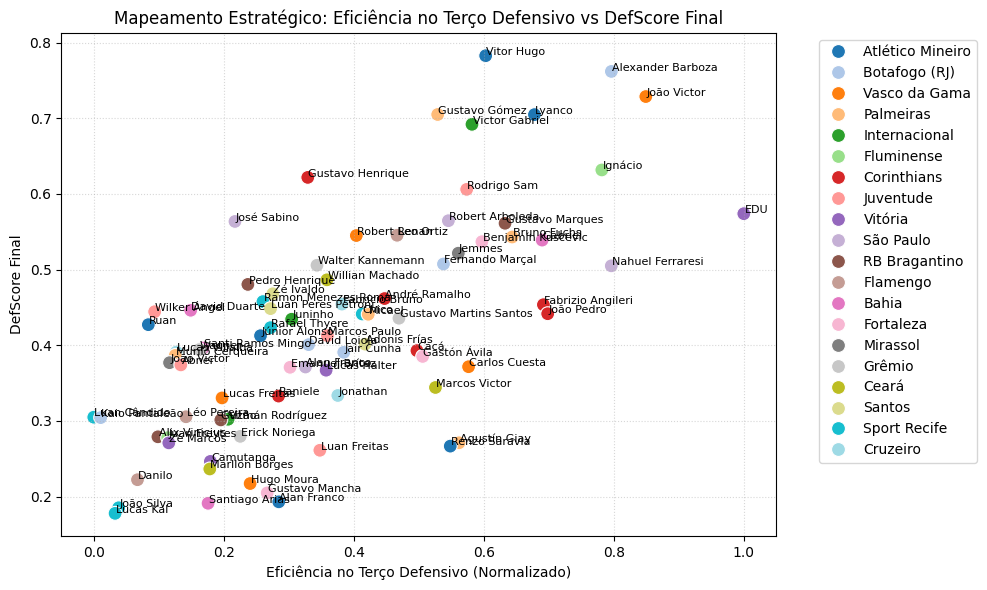

In [ ]:
#  Mapeamento Gráfico de Dispersão (Seção 8.2)

# Configuração básica do Scatter Plot para mapeamento estratégico
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ranking_def, x='def3rd_eff_final', y='DefScore_final', hue='Squad', s=100, palette='tab20')

# Laço compacto focado em rotular textualmente os pontos de cada atleta no plano cartesiano
for i, row in df_ranking_def.iterrows():
    plt.text(row['def3rd_eff_final'] + 0.001, row['DefScore_final'] + 0.001, row['Player'], fontsize=8)

plt.title("Mapeamento Estratégico: Eficiência no Terço Defensivo vs DefScore Final")
plt.xlabel("Eficiência no Terço Defensivo (Normalizado)")
plt.ylabel("DefScore Final")
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Painel Executivo Interativo com Widget e Radar (Seção 8.3)

# Mapeamento estético dos eixos nominais e definições estruturais para o Radar Plot
friendly_metrics = ['Impacto Aéreo', 'Eficiência Def 3rd', 'Interceptações (PAdj)', 'Bloqueios (PAdj)', 'Cortes (PAdj)']
metrics_radar = ['Aerial_Score_final', 'def3rd_eff_final', 'Int_adj_final', 'block_sh_adj_final', 'Clr_adj_final']
colors_radar = px.colors.qualitative.Set1

# Segmentações estratégicas de mercado (Listas alvo para tomada de decisão)
scout_titulares = [
    ('Alexander Barboza', 'Botafogo (RJ)'), ('João Victor', 'Vasco da Gama'),
    ('Gustavo Henrique', 'Corinthians'), ('Gustavo Gómez', 'Palmeiras')
]
scout_elenco = [
    ('Gustavo Martins Santos', 'Grêmio'), ('João Pedro', 'Corinthians'),
    ('Marcos Paulo', 'Juventude')
]

# Encapsulamento lógico para a renderização direta e segura dos polígonos no Plotly
def renderizar_radar_estatico(lista_atletas, titulo_contexto):
    df_selected = df_ranking_def[
        df_ranking_def.apply(lambda x: (x['Player'], x['Squad']) in lista_atletas, axis=1)
    ]
    fig = go.Figure()
    for idx, (_, row) in enumerate(df_selected.iterrows()):
        fig.add_trace(go.Scatterpolar(
            r=row[metrics_radar].values,
            theta=friendly_metrics,
            fill='toself',
            name=f"{row['Player']} ({row['Squad']})",
            line=dict(color=colors_radar[idx % len(colors_radar)], width=2),
            opacity=0.55
        ))
    fig.update_layout(
        title=titulo_contexto,
        polar=dict(radialaxis=dict(visible=True, range=[0, 1], tickvals=[0, 0.25, 0.5, 0.75, 1], gridcolor='lightgrey')),
        showlegend=True,
        template='plotly_white'
    )
    fig.show()

# ------------------------------------------------------------------------------
# EXECUÇÃO IMEDIATA: Renderização sequencial estável para o Portfólio
# ------------------------------------------------------------------------------

# 1. Gráfico de Radar - Alvos de Elite para Titularidade
renderizar_radar_estatico(scout_titulares, "Prospecção de Mercado: Alvos de Elite para Titularidade (Perfil A)")

# 2. Gráfico de Radar - Alvos Custo-Benefício para Composição de Elenco
renderizar_radar_estatico(scout_elenco, "Prospecção de Mercado: Alvos Custo-Benefício para Elenco (Perfil B)")
